## Jupyter-Notebook zur Datenauswertung des Myon-Versuchs

Dieses Notebook enthält den Code zur Bestimmung der Myon-Lebensdauer aus Daten, die mit dem
Versuchsaufbau im Fortgeschrittenenpraktikum aufgezeichnet werden. Bei den Daten handelt es
sich um in Echtzeit selektierte Signaturen mit Doppelpulsen, von denen der erste von einem
in den großflächigen Myon-Detektoren nachgewiesenen Myon stammt; der zweite Puls ist entweder
eine Zufallskoinzidenz im Zeitfenster von 14 µs oder stammt von einem Zerfallselektron
eines in oder in der Nähe der Detektoren gestoppen Myons. 

Das angenommene Datenformat ist eine CSV-Datei, wie sie mit der Konfigurationsdatei 
`lifetime_setup.yaml` aufgezeichnet wurden. Als Modellfunktion wird eine exponetielle 
Verteilung der Myon-Lebensdauern mit einem konstanten Untergrund aus Zufallskoinzidenzen
angenommen. Die freien Parameter des Modells sind die (mittlere) Myon-Lebensdauer $\tau_\mu$
und der Anteil $f$ an zufälligen Koinzidenzen im (konfigurierbren) Zeitfenster zwischen 0.5 
und 14.5µs nach dem Triggerpuls. Wegen der geringen Anzahl von Ereignissen, die in etwa 30 min 
aufgezeichnet werden, wird eine auf dem negativen Logarithmus der Likelihood-Funktion basierende
Methode verwendet ("unbinned log-likelihood fit").

Zur Filterung der Daten wird das Datenanalysewerkzeug `pandas`verwendt. Zur Modellanpassung
werden die Funktionen der Pakte `PhyPraKit` und `kafe2` empfohlen. Im Bedarfsfall finden 
sich notwendige Hingergrundinformationen in den Jupyter-Tutorials `pandasBasics.ipynb`, 
`negLogLFits,ipynb` und `advancedFitting.ipynb` unter der URL https://etp.kit.edu/~quast/jupyter .


### Messung der Lebensdauer gestoppter Myonen

Dieses Notebook ist vollständig und soll nach den Einstellungsarbeiten am Versuchsaufbau auf erste
Testdaten angewandt werden, um als Verifikation der korrekten Konfiguration mit einer Messung von 
ca. 30 min Dauer die Myon-Lebensdauer mit einer Genauigkeit von ca. $\pm$0.5µs zu bestimmen. 

Die vorgestellten Methoden können direkt auf die in der Langzeitmessung mit eingeschaltetem Magnetfeld erhaltenen
Daten übertragen werden. 

### 1. Import aller benötigten Programmpakete

In [1]:
import time
import numpy as np     
import pandas as pd                 # mächtiges Paket zur Handhabung großer Datensätze
import matplotlib.pyplot as plt     # Grafikbibliothek
# Pakete zur Modellanpassung ("Wrapper-Fuktionen in PhyPraKit)
from PhyPraKit import mFit, hFit, k2hFit

### 2. Einlesen der Daten

In [21]:
LT1 = "lifetime1.txt"   # data in csv-Format produced with config `lifetime_setup.yaml`

# convenient abbreviations for column names
# - for measurements with 3 panels
dp_columns_3p = { 0:'EvId',  1:'EvT', 2:'tDead', 3:'dT', 
               4: 'h1A',  5:'p1A', 6: 'I1A',
               7: 'h1B',  8:'p1B', 9: 'I1B', 
               10: 'h1C', 11:'p1C', 12:'I1C', 
               13:'h2A', 14:'p2A', 15:'I2A', 
               16:'h2B', 17:'p2B', 18:'I2B', 
               19:'h2C', 20:'p2C', 21:'I2C',
                }
# - for measurements with 4 panels
dp_columns_4p = { 0:'EvId',  1:'EvT', 2:'tDead', 3:'dT', 
               4: 'h1A',  5:'p1A', 6: 'I1A',
               7: 'h1B',  8:'p1B', 9: 'I1B', 
               10: 'h1C', 11:'p1C', 12:'I1C', 
               13: 'h1D', 14:'p1D', 15:'I1D', 
               16:'h2A', 17:'p2A', 18:'I2A', 
               19:'h2B', 20:'p2B', 21:'I2B', 
               22:'h2C', 23:'p2C', 24:'I2C',
               25:'h2D', 26:'p2D', 27:'I2D'
                }

# read the data and store in a pandas dataframe
lifetime_df = pd.read_csv( LT1,
     skiprows=1, comment='#', delimiter='\t', header=None).rename(columns = dp_columns_4p)
# adjust time unit - was µs in old data, now s
time_unit= 1.e-6 # adjust if time is in µs
 

### 3. Qualitätskontrolle der aufgezeichneten Daten

Als erstes empfiehlt es sich, zunächst die Qualität der Daten zu überpüfen:

   - statistische Information zur Datennahme
   - zeitlicher Verlauf der aufgenommenen Daten
   - Pulshöhenverteilung


In [22]:
import time
from scipy.stats import trim_mean

def dataquality_check(df):
    """check data quality of data in dataframe df
    """
    # print information  on data (from header)
    header = df[['EvT','EvId', 'tDead']]
    print('** Infomation on data:')

    # event times in seconds 
    EvT_s = header['EvT']*time_unit  # event times in s 

    # plot trigger and event rate
    print('  Date of 1st Event: ', time.ctime(EvT_s.values[0]))
    print('  Date of last Event:', 25*' ', time.ctime(EvT_s.values[-1]))

    NEvents = header['EvId'].values[-1]
    Nsel = len(header['EvId'])
    Duration = (EvT_s.values[-1] - EvT_s.values[0])
    print('     triggered Events: {}  selected Pulses: {}  Duration: {}s  Rate: {:.1f}Hz'.format(
        NEvents, Nsel, Duration, NEvents/Duration))
    Tbetween = np.diff(EvT_s.to_numpy()) # in seconds
    print('     mean time between selected pulses: {:.2g}s'.format(Tbetween.mean()))

    T0 = EvT_s[0]
    #  -  number of events triggered between selected events in data set
    dN = np.diff(header['EvId'].to_numpy())
    Nbins= 100
    Wbin = Duration/Nbins
    _ = plt.hist(EvT_s[1:] - T0, weights = dN, bins=Nbins, rwidth=0.6, label='trigger rate', alpha=0.5)
    _ = plt.hist(EvT_s[1:] - T0, bins=Nbins, rwidth=0.6, label='rate', alpha=0.5, )
    plt.text(0.1, 0.9, "Bin Width={:.3g}s".format(Wbin), color = 'darkred', transform=plt.gca().transAxes)
    plt.yscale('log')
    plt.suptitle('Event Rate')
    plt.xlabel('time since start (s)')
    plt.ylabel('# entries / bin')
    plt.legend(loc='upper right')
    plt.show()

    # plot time between events                                
    _ = plt.hist(Tbetween[Tbetween < Tbetween.mean()*100], bins=50, log=True)
    plt.xlabel('Time between events (s)')
    plt.ylabel('# entries / bin')

    plt.show()

    # show pulse height distributions
    df['h1A'].hist(bins=100, log=False)
    plt.xlabel('pulse heights 1st pulse Panel A (mV)')
    plt.show()
    df['h1B'].hist(bins=100, log=False)
    plt.xlabel('pulse heights 1st pulse Panel B (mV)')
    plt.show()
    df[df['h2B']>0.]['h2B'].hist(bins=100, log=False)
    plt.xlabel('pulse heights 2nd pulse Panel B (mV)')
    plt.show()
    df[df['h2C']>0.]['h2C'].hist(bins=100, log=False)
    plt.xlabel('pulse heights 2nd pulse Panel C (mV)')
    plt.show()


 *** Data quality checks ***

** Infomation on data:
  Date of 1st Event:  Thu Jan  1 01:29:08 1970
  Date of last Event:                           Thu Jan  1 01:29:08 1970
     triggered Events: 261513  selected Pulses: 485  Duration: 0.0024546798442770523s  Rate: 106536500.3Hz
     mean time between selected pulses: 5.1e-06s


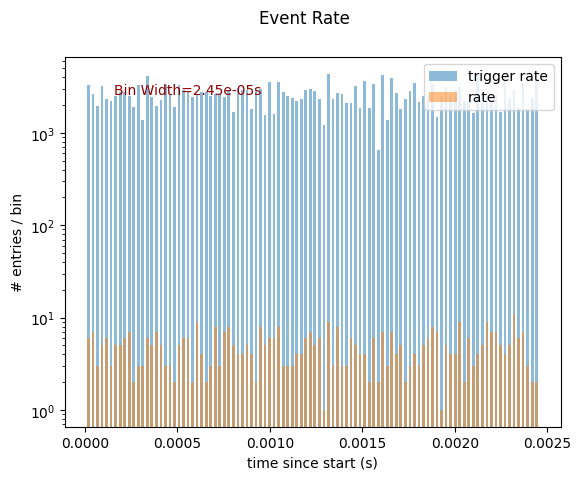

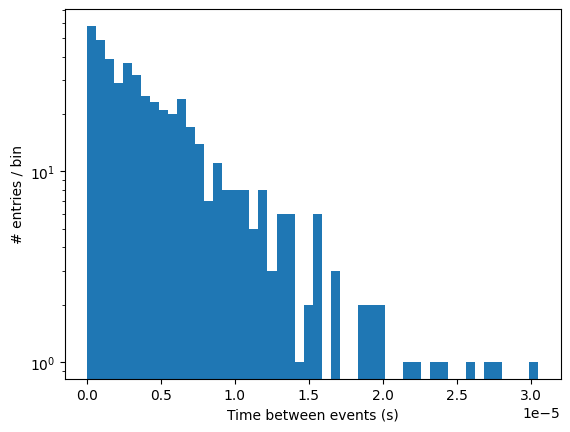

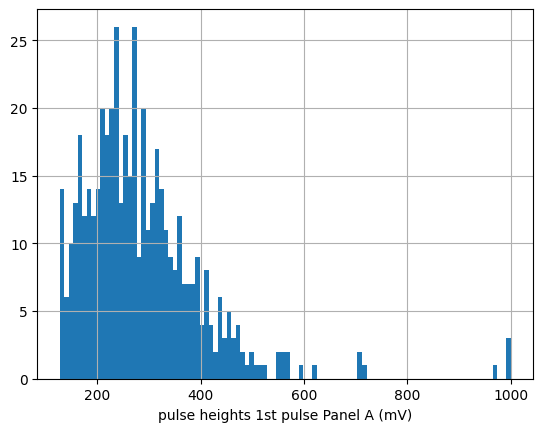

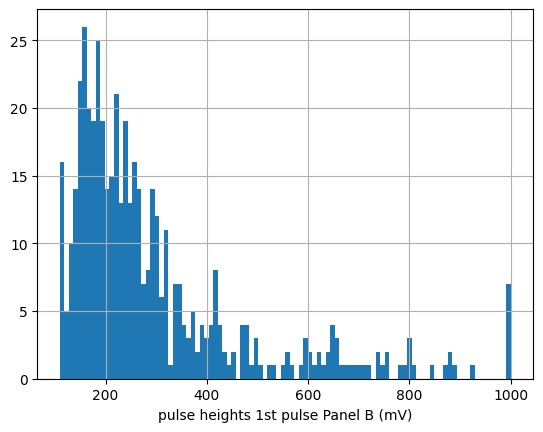

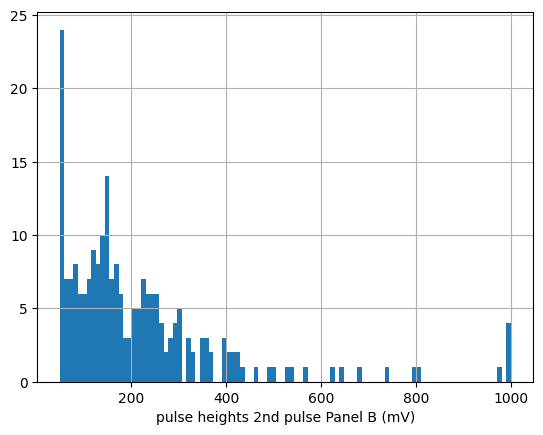

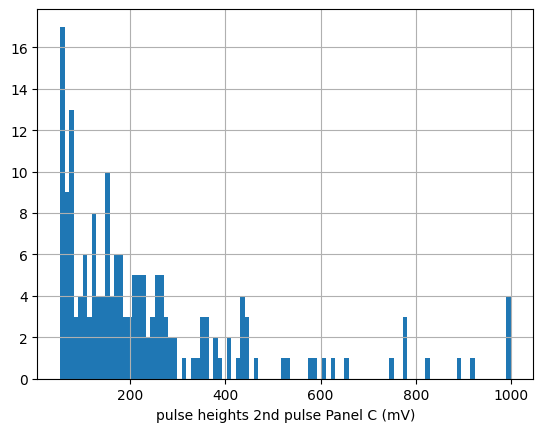

In [23]:
print("\n *** Data quality checks ***\n")
dataquality_check(lifetime_df)

### 4. Verteilung der Zeiten zwischen Doppelpulsen

Wenn die Verteilungen oben den Erwartungen entsprechen, werden im nächsten Schritt die 
Daten gefiltert, um den Anteil an validen Doppelpulsen zu optimieren. Dazu werden die
schon bei der Datennahme betrachteten Kriterien verschärft. 

Sie werden sehen, dass *pandas* bei der Datenselektion sehr effiziente und mächtige
Methothen bereit stellt, insbesondere das Indizieren von Zeilen in den Daten mit einer
Bool'schen Maske, über die Auswahlkriterien definiert und in einem Schritt auf den 
gesamten Datensatz angewendet werden können. 

Zunächst werden ein passendes Zeitfenster sowie Schwellenwerte für die betrachteten
Pulshöhen festgelgt. Zur Selektion wird weiter verlangt, dass es eine Koinzidenz der 
ersten Pulse in mindestens zwei der Panels gab; so wird sichgergestellt, dass der Start 
auf jeden Fall ein echtes Myon und keine Zufallskoinzidenz war.  Einen zweiten Puls soll 
es in mindestens einem der Panels gegeben haben. Zur Überprüfung wird die Verteilung der 
Pulshöhen anschließend histogrammiert.

*Anmerkung:* Die Zeiteinheit der aufgezeichneten Daten war ns; die Faktoren 1e9 sorgen
für die Umwandlung in die in den folgenden Schritten bevorzugte Zeiteinheit Sekunden. 
  

In [24]:
# acceptance definition 

# -----------------------------------------------
# valid life time interval
a0 = 1.0e-6
b0 = 14.5e-6

# pulse height thresholds for trigger pulse in Panels A & B
th_1A_low = 75
th_1A_high = 1100 # not effective above 1. !
th_1B_low = 75
th_1B_high = 1100
th_1C_low = 50.
th_1C_high = 1100.
th_1D_low = 50.
th_1D_high = 1100.

# pulse height thresholds for 2nd pulse in Panels B ("Top") & C ("Bottom")
th_2A = 75.
th_2B = 75.
th_2C = 75.
th_2D = 75.

# -----------------------------------------------

def select(df, signature = None):
    """Define acceptance for "good evnts"
       - myon stopped in copper plate
       - decay to top or bottom detectors
    """

    # criteria for 2-fold coincidences
    mask_AB = (df['h1A'] > th_1A_low)  & (df['h1A'] < th_1A_high) & \
                (df['h1B'] > th_1B_low)  & (df['h1B'] < th_1B_high) 
    mask_AC = (df['h1A'] > th_1A_low)  & (df['h1A'] < th_1A_high) & \
                (df['h1C'] > th_1C_low)  & (df['h1C'] < th_1C_high)
    mask_BC = (df['h1B'] > th_1B_low)  & (df['h1B'] < th_1B_high) & \
                (df['h1C'] > th_1C_low)  & (df['h1C'] < th_1C_high) 
    mask_AD = (df['h1A'] > th_1A_low)  & (df['h1A'] < th_1A_high) & \
                (df['h1D'] > th_1D_low)  & (df['h1D'] < th_1D_high)
    mask_BD = (df['h1B'] > th_1B_low)  & (df['h1B'] < th_1B_high) & \
                (df['h1D'] > th_1D_low)  & (df['h1D'] < th_1D_high) 
    mask_CD = (df['h1C'] > th_1C_low)  & (df['h1C'] < th_1C_high) & \
                (df['h1D'] > th_1D_low)  & (df['h1D'] < th_1D_high) 
    
    # criteria for stopped muon in copper plate
    mask_stopped = (df['h1A'] > th_1A_low)  & \
                   (df['h1A'] < th_1A_high) & \
                   (df['h1B'] > th_1B_low)  & \
                   (df['h1B'] < th_1B_high) & \
                   (df['h1C'] < th_1C_low)  & \
                   (df['h1D'] < th_1D_low) 
 
    # bookean mask for 2nd pulses: one valid pulse in either A, B, C or D    
    mask2_up =  (df['h2A'] > th_2A) | (df['h2B'] > th_2B) 
    mask2_down =  (df['h2C'] > th_2C) | (df['h2D'] > th_2D)  

    if signature == "all":        

      # select set of conditions
        filter_mask = (mask_AB | mask_AC | mask_BC |  \
                       mask_AD | mask_BD | mask_BD ) & \
                      (mask2_up | mask2_down)

      # apply filter conditions
        sel = lifetime_df[ filter_mask]
        print('shape of selected data:    ', sel.shape)
        return sel
    
    elif signature == "top":
      # select events with stopped muon in copper and decay to top detectors
        Tsel = df[ mask_stopped & mask2_up]
        print('shape top detector:    ', Tsel.shape)
        return Tsel
        
    elif signature == "bottom":
      # selecct events with stopped muon in copper decay to bottom detectors
        Bsel = df[ mask_stopped & mask2_down]
        print('shape bottom detector: ', Bsel.shape)
        return Bsel
    else:
        print('!!! unknown signature')
        return None

shape of selected data:     (400, 28)
 ** number of selected events:  331


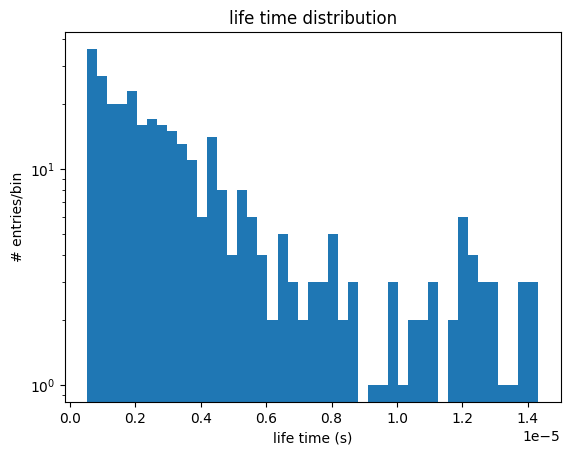

In [25]:
# Filter events
Tsel = select(lifetime_df, "all")

# Plot lifetime distribution
# --------------------------

# - acceptance definition: valid life time interval
a0 = 0.5e-6
b0 = 14.5e-6

# - select data in range [a0, b0]
dT = Tsel[ (Tsel['dT'] > a0*1e9) & (Tsel['dT'] < b0*1e9)].dT.values*1.0e-9
print(" ** number of selected events: ", len(dT))

# show result in a histogram
nbins = 45
bin_entries, bin_edges, _ = plt.hist(dT, bins=nbins)
plt.title('life time distribution')
plt.xlabel('life time (s)')
plt.ylabel('# entries/bin')
#plt.ylim(0,1000)
plt.yscale('log')
plt.savefig("lifetime_distribution")
plt.show()

### 5. Anpassung von exponentieller Lebensdauer- und Untergrund-Verteilung. 

Als letzen Schritt führen wir die Modellanpassung durch. Die als Verteilungsdichte aufgefasste,
d.h. auf Eins normierte Modellfunktion sieht wie folgt aus: 

In [26]:
def exp_decay(t, tau=2.19e-6, f=0.1, a=a0, b=b0):
    """
    Probability density of an exponential decay on top of a flat background in interval [a0, b0]
    """
    return (1 - f) * np.exp(-t / tau) / (tau * (np.exp(-a / tau) - np.exp(-b / tau))) + \
             f / (b - a)

Da wir nur einge Hundert Ereignisse übrig haben und die Verteilung stark abfällt, ist das obige Histogramm als Basis 
der Datenauswertung nur schlecht geeignet. Daher sollte eine **Likelihood-Anpassung** direkt an die ungebinnten Daten 
durchgeführt werden. Dazu kann komfortabel die Funktion `PhyPraKit.pyhFit.mFit` verwendet werden. 

`phyFit` is a very staight-forward interface to the mimimization and error analyis package `iminuit`.
`mFit` implements a fit based on the negative log-likelihood of a user-defined probability-density 
function for unbinned data. 

**Note** that the fit range is reflected by the parameters *a* and *b* in the density function;  these are not
free parameters of the fit and are therefore declared as *fixed* in the options passed to the fitting procedure. 

**Note2**: The more universal fitting package *kafe2* contains a similar example in the subdirectory 
`examples/010_unbinned_fit/01_unbinned.py` which can be adapted to be used here.  

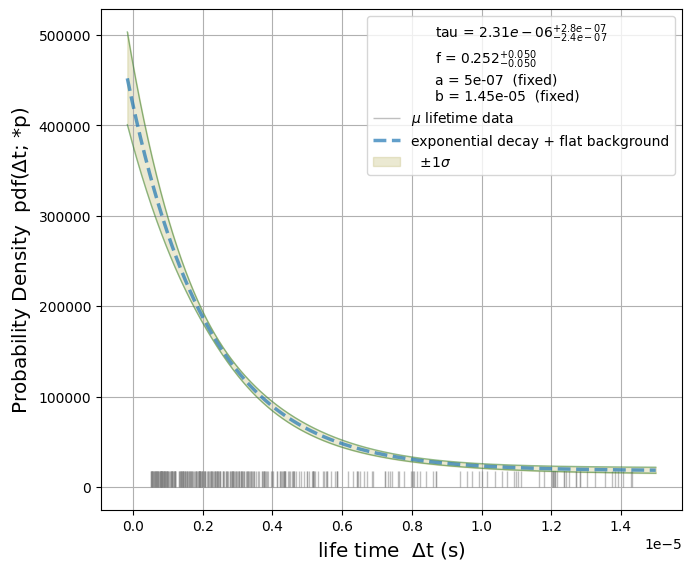


*==* unbinned ML Fit Result:
 parameter names:        ['tau' 'f' 'a' 'b']
 parameter values:       [2.30518287e-06 2.51521904e-01 5.00000000e-07 1.45000000e-05]
 neg. parameter errors:  [-2.40662371e-07 -4.95486433e-02]
 pos. parameter errors:  [2.81836824e-07 4.98913768e-02]
 correlations : 
 [[ 1.         -0.61057226]
 [-0.61057226  1.        ]]


In [27]:
from PhyPraKit.phyFit import mFit  

# Fit time between pulses
results = mFit( exp_decay,        # the paramter-dependent pdf
       data = dT,                 # data  
       limits=('f', 0., 1.),      # parameter limits
       fixPars = ['a', 'b'],      # fixed parameter(s) 
       neg2logL = True,           # use -2*ln(L)
       plot=True,                 # plot data and model
       plot_band=True,            # plot model confidence-band
       plot_cor=False,            # do not plot profiles likelihood and contours
       axis_labels=['life time  ' + '$\Delta$t (s)', 
                       'Probability Density  pdf($\Delta$t; *p)'], 
       data_legend = '$\mu$ lifetime data',    
       model_legend = 'exponential decay + flat background' )
# Print results 
pvals, perrs, cor, gof, pnams = results.values()
print('\n*==* unbinned ML Fit Result:')
print(" parameter names:       ", pnams)
print(" parameter values:      ", pvals)
print(" neg. parameter errors: ", perrs[:,0])
print(" pos. parameter errors: ", perrs[:,1])
print(" correlations : \n", cor)  


## *Aufgabe:* Ergebnis kommentieren und bewerten !

## Nachtrag

Damit ist dieser Aufgabenteil abgeschlossen. Wenn Sie mit der erhaltenen Lebensdauer zufrieden sind, sollten Sie nun die 
Langzeitmessung mit eingeschaltetem Magnefeld starten. 

Während Sie auf die ertsten Daten warten, sollten Sie sich noch einmal diesem Notebook widmen und den Unterschied
zwischen einem ungebinnten log-Likelihood-Fit und einer Anpassung an ein Histogramm anschauen. Für den großen Datensatz,
den die Langzeitmessung produzieren wird, ist nämlich das oben verwendete Verfahren numerisch sehr ineffizient, weil für
jedes Ereignis einzeln in jedem Iterationsschritt der Anpassung der negative Logarithmus berechnet werden muss. 
Bei einer Anpassung direkt an das Histogramm, das wir oben schon erzeugt hatten, müssen jeweils nur die Anzahlen 
der Einträge in den einzelnen Bins betrachtet werde. Für große Anzahlen an registrierten Doppelpulsen sind die
Verfahren praktisch identisch, und daher kann dann das numerisch effizientere verwendet werden. 

Probieren Sie nun den Histogram-Fit aus, den Sie auch für die Lanzeitdaten verwenden können. Mit den zur Verfügung
gestellten Wrapper-Funktionen ist das mit *PhyPraKit.phyFit* oder *kafe2* kein Problen. 

## Binned log-likelihood fit with `PhyPraKit` 

For large data sets, a fit to a historgram assuming a Poisson distribution of the numbers of entries
produces results that are equivalent to an unbinned fit with much less computational effort. Note
that binning leads to a loss of information because values are approximated by the bin center
they fall into. 
The interface `hFit` of the package `PhyPraKit.phyFit` provides an easy way to perform such a fit 
to the same user-defined density function thas has been used above in the unbinned case. Note that also 
Bins with  small or no entries are treated correctly by this package (and not simply ignored as in many 
other programs). 

**Hint**: *Use this version for the fits to the large data sets required for the spin measurement.* 

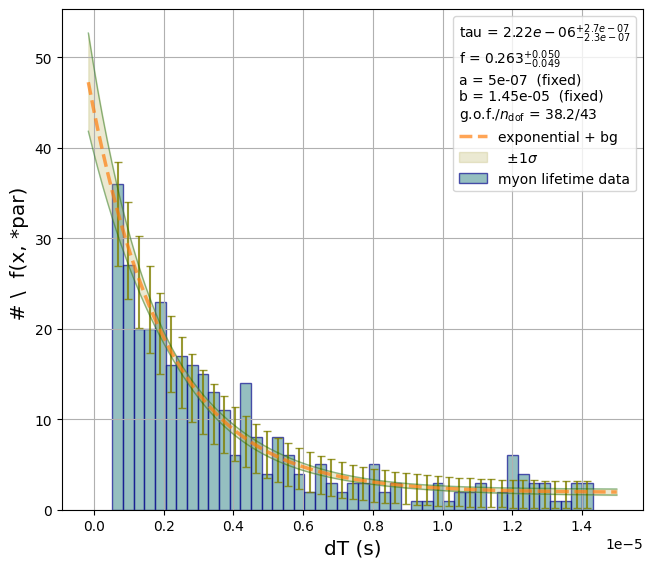


*==* binned ML Fit Result:
 parameter names:        ['tau' 'f' 'a' 'b']
 goodness-of-fit: 38.2
 parameter values:       [2.22327362e-06 2.63497302e-01 5.00000000e-07 1.45000000e-05]
 neg. parameter errors:  [-2.32531846e-07 -4.90802724e-02]
 pos. parameter errors:  [2.70725321e-07 4.96379584e-02]
 correlations : 
 [[ 1.         -0.60177042]
 [-0.60177042  1.        ]]


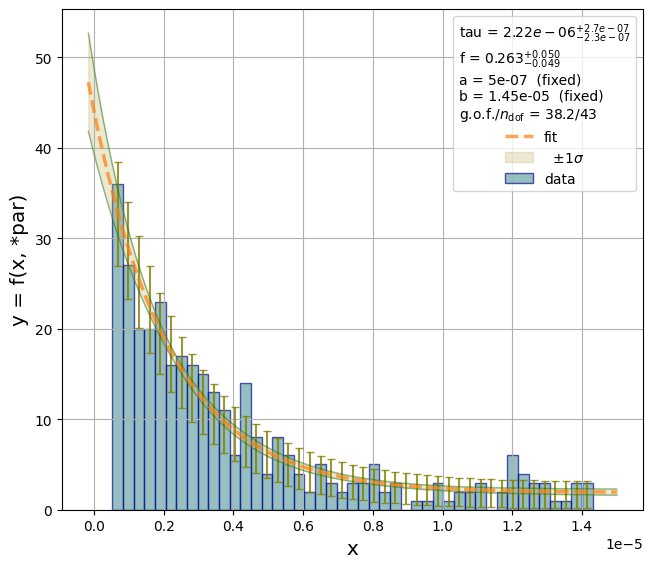

In [28]:
from PhyPraKit.phyFit import hFit

#  
# ---  perform fit  to Top data with phyFit.hFit 
#       using the histogram produced above 
#

hFit_result = hFit( 
       exp_decay,               # the fit model
       bin_entries, bin_edges,  # bin entries and bin edges
       limits=('f', 0., 1.),    # parameter limits
       fixPars = ['a', 'b'],    # fix parameter(s) 
       plot=True,               # plot data and model

       plot_band=True,          # plot model confidence-band
       plot_cor=False,          # plot profiles likelihood and contours
       axis_labels=['dT (s)', '  # \  f(x, *par)'], 
       data_legend = 'myon lifetime data',    
       model_legend = 'exponential + bg',
       return_fitObject = True
    )
hFit_result.plotModel()
plt.savefig("lifetime_hist_fit")
# Print results 
pvals, perrs, cor, gof, pnams = hFit_result.getResult().values()
print('\n*==* binned ML Fit Result:')
print(" parameter names:       ", pnams)
print(" goodness-of-fit: {:.3g}".format(gof))
print(" parameter values:      ", pvals)
print(" neg. parameter errors: ", perrs[:,0])
print(" pos. parameter errors: ", perrs[:,1])
print(" correlations : \n", cor)  



In [29]:
## *Aufgabe:* Ergebnis kommentieren und bewerten !

Nachtrag:  Für die spätere Anwendung wird es notwendig, die Profil-Likelihood bzgl. eines Parameters zu erzeugen und anzuzeigen.
Dazu dient die Funktion `hfit.plot_Profile(parameter, range=(<min>, <max>)`. Ein Beispiel sieht so aus:

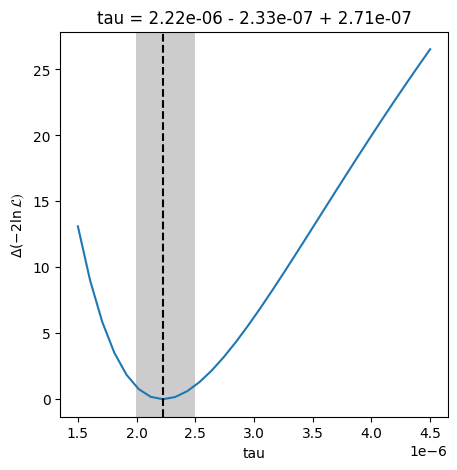

In [30]:
p2nlL = hFit_result.plot_Profile('tau', range=(1.5e-6, 4.5e-6) )
plt.savefig("lifetime_tau_LL")

Aus der Profil-Likelihood lassen sich Konfidenzintervalle um den Bestfit-Wert oder auch Ausschlussgrenzen für den entsprechenden Parameter ablesen. Auch zur Beurteilung der Signifikanz einer beobachteten Spin-Oszillation werden wir diese Methode später verwenden.

## Alternative using `kafe2`

The `kafe2`package offers a number of options to control binned likelihood fits. It is therefore more
convenient to use a wrapper-function as provided by `PhyPraKit.k2hFit`. This is shown in the example 
below. 

**Note** that the details of the implemenations of the binned fit differ between *kafe2* and *phyFit*, 
e.g. the precision for the integration of the density distribution over bins to obtain the predicted
number of entries in each bin.  

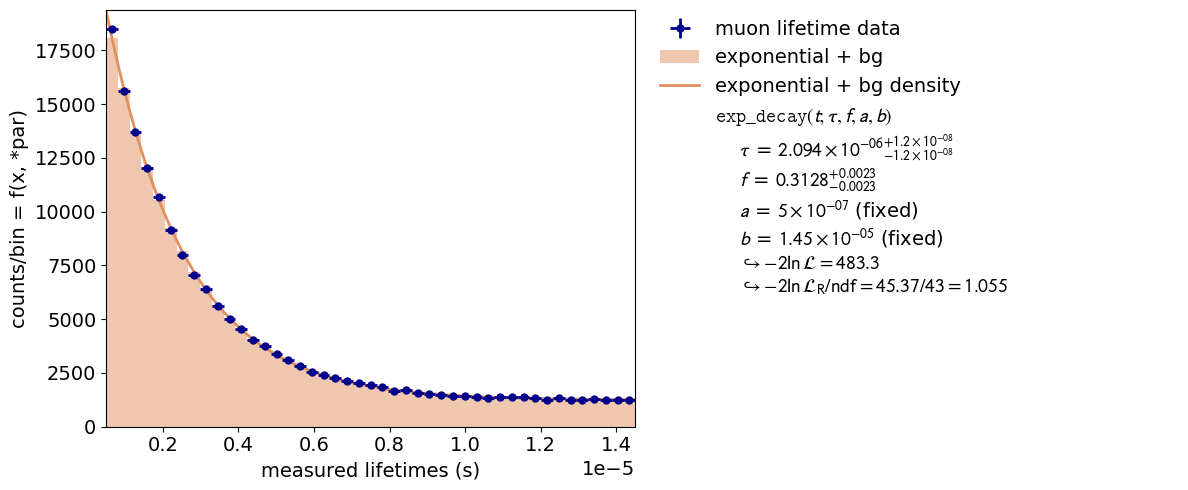

In [17]:
from PhyPraKit import k2hFit

par_values, par_uncert, cor, gof = k2hFit( 
       exp_decay,                         # the fit model
       dT,                                # the raw data 
       bin_edges,                         # bin edges
       p0 =[2.e-6, 0.3, a0, b0],          # initial values
       limits=('f', 0., 1.),              # parameter limits
       fixPars = [['a', a0], ['b', b0]],  # fix parameter(s) 
       use_GaussApprox = False,  # Poisson Likelihood
       plot = True, plot_cor = False,
       showplots = True, plot_band=True, plot_residual=False,
       quiet = True,
       axis_labels = ['measured lifetimes (s)', 'counts/bin = f(x, *par)'],
       data_legend = 'muon lifetime data',    
       model_legend = 'exponential + bg',
       model_expression=None,
       model_name=None, 
       model_band = r'$\pm 1 \sigma$',           
       fit_info=True, asym_parerrs=True    
    )

*Anmerkung:*  Der Wert für $-2{\rm ln}{\cal L}$ entspricht dem Wert des zweifachen des negativen Logarithmus der Likelihood
am Optimum. Vergleicht man zwei Anpassungen, z.B. mit einem Parameter der einmal frei gelassen und im anderen Fall auf einen
festen Wert fixiert wird, so entspicht die Differenz der Werte für $-2{\rm ln}{\cal L}$ dem Quadrat des sogenannten $z$-Wertes,
der für Hyothesentests relevant ist, wie wir ihn für die Auswewrtung der Langzeit-Messung benötigen.

*Übrigens*: Der Wert $-2{\rm ln}{\cal L_R/{\rm ndf}}$ ist ein Maß für die Güte der Anpassung ("gof = goodnes of fit) und 
entspricht dem Wert für $\chi^2$ pro Freiheitsgrad bei Anpassungen mit Gauß-förmigen Unsicherheiten - für große Werte der
Bin-Einträge konvergiert gof/ndf gegen $\chi^2$/ndf.

## Ausblick

Zur Auswertung der Langzeit-Daten müssen Sie im vorgeschlagenen Verfahren nur die Modellfunktion für den exponentiellen Zerfall 
durch das in der Anleitung beschriebene Modell mit Modulation ersetzen und die Selektionskriterien anpassen, um möglichst viele
in der Kupferplatte gestoppe Myonen im Datenatz anzureichern. Da mit den Daten einer Woche keine stabile Anpassung
aller im Modell vorhandenen freien Parameter möglich ist, sollten Sie die Parameter auf einen für einen Myon-Spin von 1/2 erwartete
Werte setzen. Als freier Parameter kommt dann im Modell nur die Modulationsamplitude ins Spiel, den Sie genau wie
die Lebensdauer und den Untergrundanteil anpassen müssen. 

Zur Überprüfung der Signifikanz verwenden Sie dann, wie in der Anleitung beschrieben, den $z$-Wert, also die Wurzel aus der Differenz 
der -2ln(L)-Werte für die Anpassung des exponentiellen Modells mit Modulationsamplitude Null und dem Wert von -2ln(L) am Optimum. 
Diese beiden Werte können Sie entweder den jeweiligen Fit-Ergebnissen entnehmen, oder sie entnehmen Sie der grafischen Darstellung
der Profil-Likelihood. 

*Sollten Sie Fragen zur Vorgehensweise haben, klären Sie diese unbedingt mit der Betreuerin oder dem Betreuer !*